In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Hyperparameter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
learning_rate = 1e-3
n_epochs = 10

In [5]:
transform = transforms.ToTensor()

train_set = torchvision.datasets.MNIST(root = "./data3", train = True, download = True, transform = transform)
val_set = torchvision.datasets.MNIST(root = "./data3", train = False, download = True, transform = transform)

train_loader = DataLoader(dataset = train_set, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(dataset = val_set, batch_size = batch_size, shuffle = False)

In [12]:
class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = 28 * 28, out_features = 512),
            nn.ReLU(),
            nn.Linear(in_features = 512, out_features = 256),
            nn.ReLU(),
            nn.Linear(in_features = 256, out_features = 128),
            nn.ReLU(),
            nn.Linear(in_features = 128, out_features = 64),
            nn.ReLU(),
            nn.Linear(in_features = 64, out_features = 10)
        )
        
    def forward(self, x):
        return self.layers(x)

In [13]:
# Weight Initialization Function
def init_weights(m, method = "he"):
    if isinstance(m, nn.Linear):
        if method == "lecun":
            nn.init.kaiming_uniform_(m.weight, mode = "fan_in", nonlinearity = "leaky_relu") # LeCun is similar to He with fan_in
        
        elif method == "xavier":
            nn.init.xavier_uniform_(m.weight)
        
        elif method == "he":
            # PyTorch's default for linear layers is already Kaiming (he) uniform
            nn.init.kaiming_uniform_(m.weight, nonlinearity = "relu")
        
        else:
            pass
        
        if m.bias is None:
            nn.init.constant(m.bias, 0)
         

In [17]:
def train_and_evaluate(initialization_method):
    print(f"\n--- Training with {initialization_method.upper()} Initialization ---")
    
    # Create a fresh model instance for each run
    model = DeepMLP().to(device)
    
    # Apply the chose initialization
    # We use lambda function to pass the method against the init_weights
    model.apply(lambda m: init_weights(m, method = initialization_method))
    
    optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {"train_loss": [], "val_acc": []}
    
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for images, labels in tqdm(train_loader, desc = f"Epoch {epoch + 1}"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
    # Validation
        model.eval()
        n_correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                for images, labels in val_loader:
                    images, labels  = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    n_correct += torch.sum(predicted == labels).item()
                    
        val_acc = 100.0 * n_correct / len(val_loader.dataset)
        avg_epoch_loss = epoch_loss / len(train_loader)
        
        print(f"Epoch {epoch + 1}/{n_epochs} -> Train Loss: {avg_epoch_loss: .4f}, Val Acc: {val_acc:.2f}%")
        
        history["train_loss"].append(avg_epoch_loss)
        history["val_acc"].append(val_acc)
    
    return history
    


In [19]:
history_he = train_and_evaluate(initialization_method = "he")
history_xavier = train_and_evaluate(initialization_method = "xavier")
history_lecun = train_and_evaluate(initialization_method = "lecun")


--- Training with HE Initialization ---


Epoch 1: 100%|██████████| 469/469 [00:06<00:00, 68.43it/s]


Epoch 1/10 -> Train Loss:  0.2334, Val Acc: 7624.29%


Epoch 2: 100%|██████████| 469/469 [00:05<00:00, 91.90it/s]


Epoch 2/10 -> Train Loss:  0.0845, Val Acc: 7672.48%


...

Epoch 8/10 -> Train Loss:  0.0213, Val Acc: 7744.37%


Epoch 9: 100%|██████████| 469/469 [00:05<00:00, 81.23it/s]


Epoch 9/10 -> Train Loss:  0.0192, Val Acc: 7748.32%


Epoch 10: 100%|██████████| 469/469 [00:05<00:00, 81.87it/s]


Epoch 10/10 -> Train Loss:  0.0166, Val Acc: 7718.30%


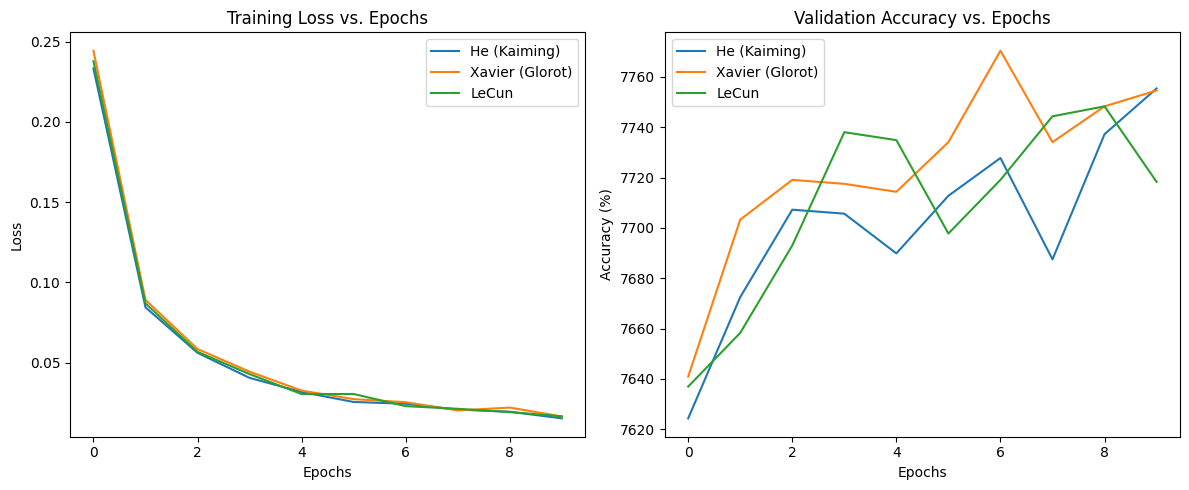

In [21]:
# Plotting
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(history_he['train_loss'], label='He (Kaiming)')
plt.plot(history_xavier['train_loss'], label='Xavier (Glorot)')
plt.plot(history_lecun['train_loss'], label='LeCun')
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_he['val_acc'], label='He (Kaiming)')
plt.plot(history_xavier['val_acc'], label='Xavier (Glorot)')
plt.plot(history_lecun['val_acc'], label='LeCun')
plt.title('Validation Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()